## Clipping an oscillator's output

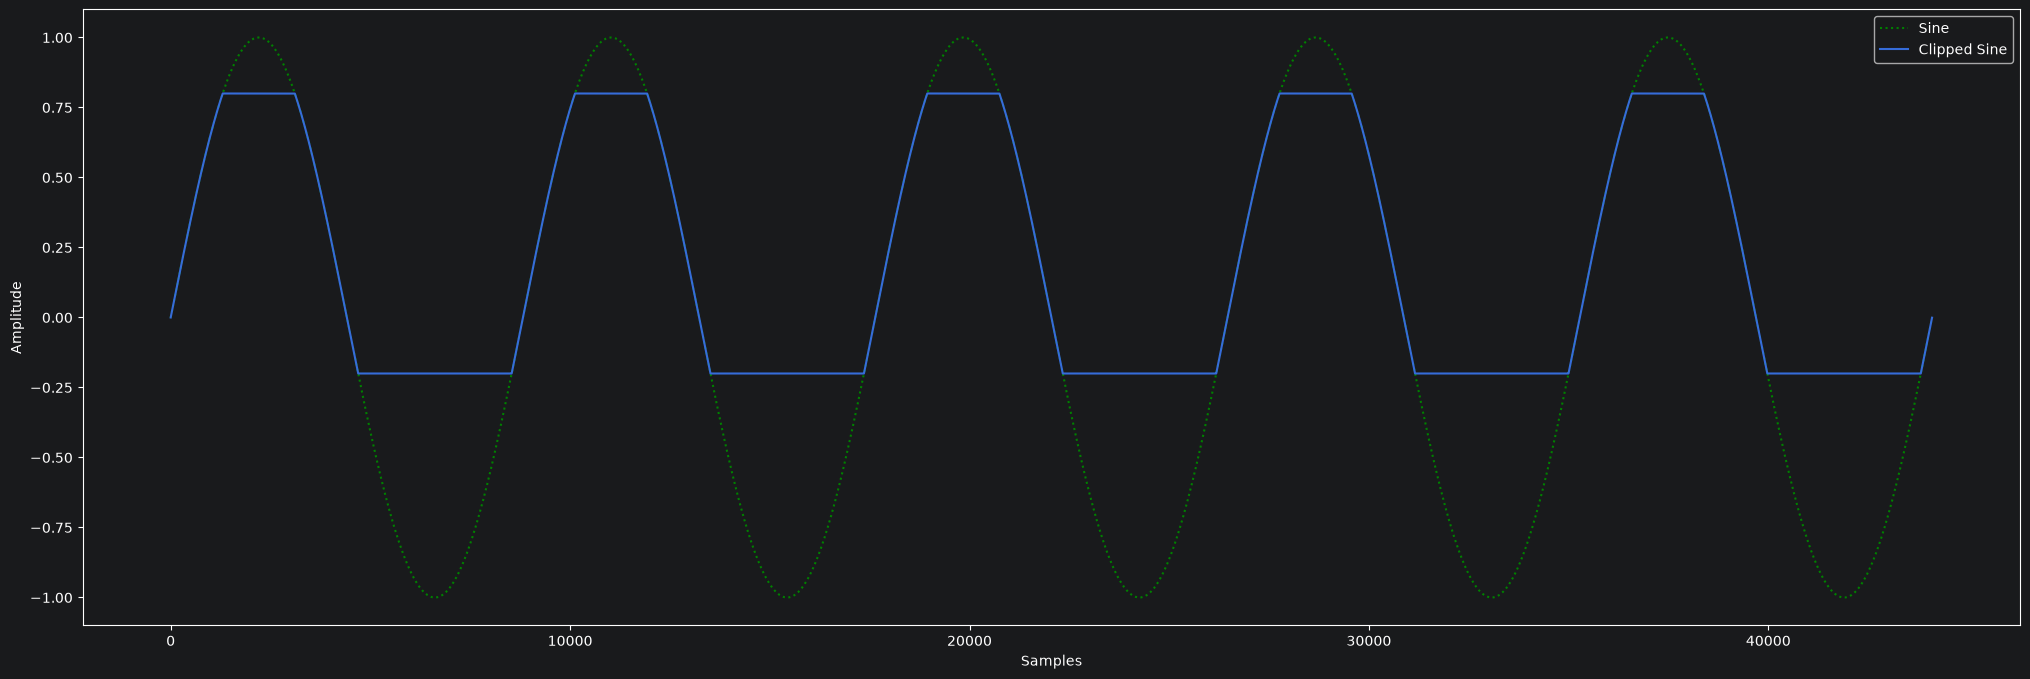

In [1]:
from matplotlib import pyplot as plt

from engine import Chain, Clipper, SineOscillator

osc = SineOscillator(frequency=5, amplitude=1, phase=0)
clipper = Clipper(wave_range=(-0.2, 0.8))
chain = Chain(osc, clipper)

plt.subplots(1, 1, figsize=(25, 8))
samples_sine = osc.get_samples(n=44100)
samples_clipped = chain.get_samples(n=44100)
plt.plot(samples_sine, linestyle=":", color="g", label="Sine")
plt.plot(samples_clipped, label="Clipped Sine")

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend()
plt.show()

## Clipping another oscillator's output

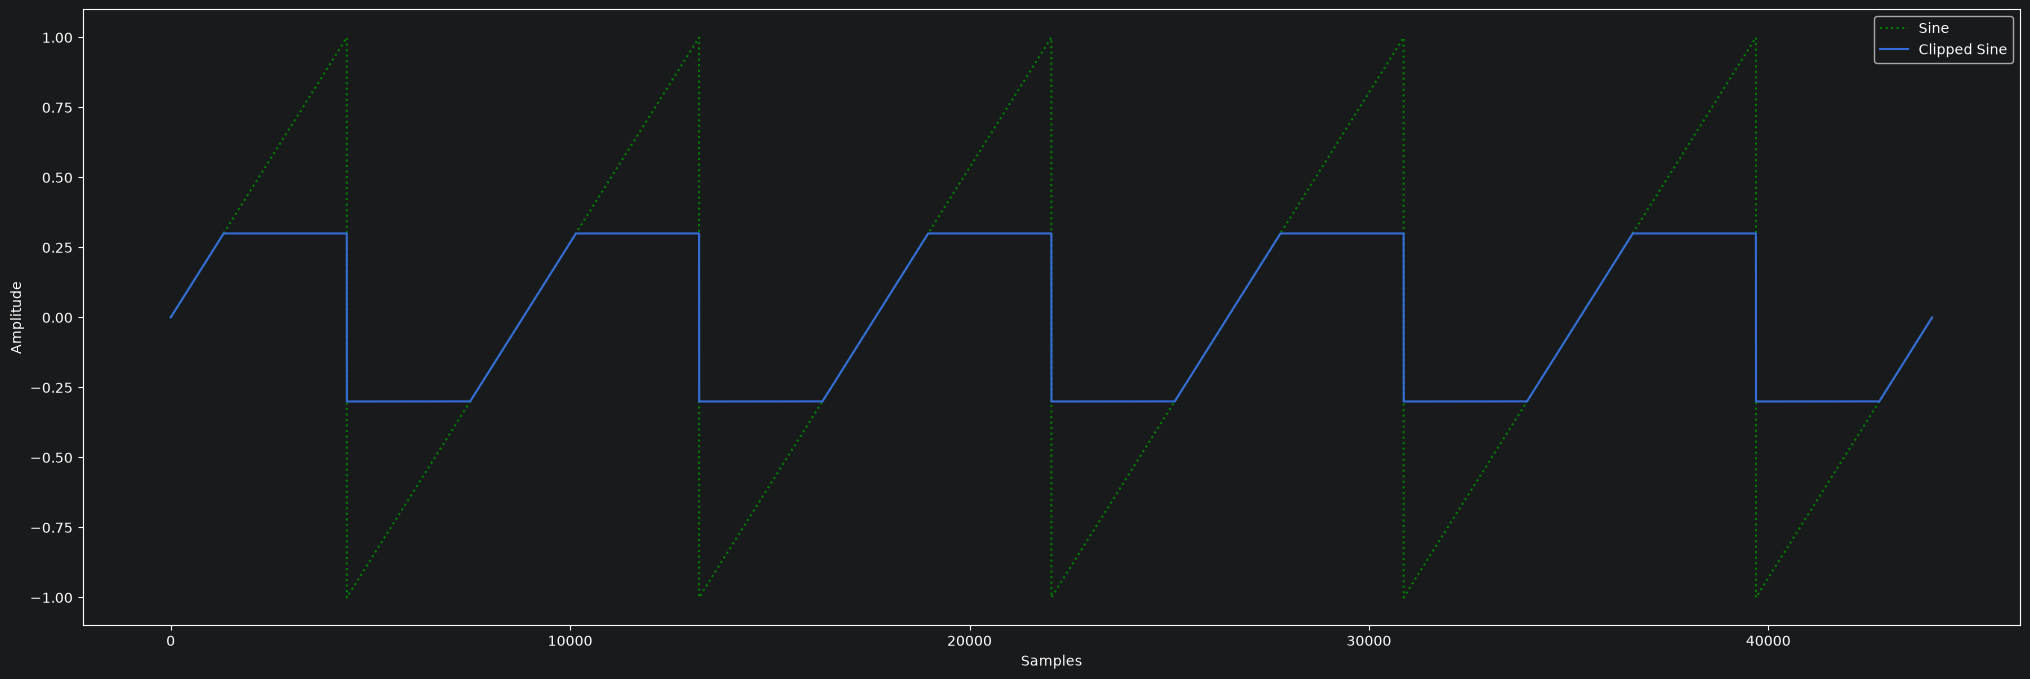

In [2]:
from matplotlib import pyplot as plt

from engine import Chain, Clipper, SawtoothOscillator

osc = SawtoothOscillator(frequency=5, amplitude=1, phase=0)
clipper = Clipper(wave_range=(-0.3, 0.3))
chain = Chain(osc, clipper)

plt.subplots(1, 1, figsize=(25, 8))
samples_sine = osc.get_samples(n=44100)
samples_clipped = chain.get_samples(n=44100)
plt.plot(samples_sine, linestyle=":", color="g", label="Sine")
plt.plot(samples_clipped, label="Clipped Sine")

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend()
plt.show()

## Modulated Clipping

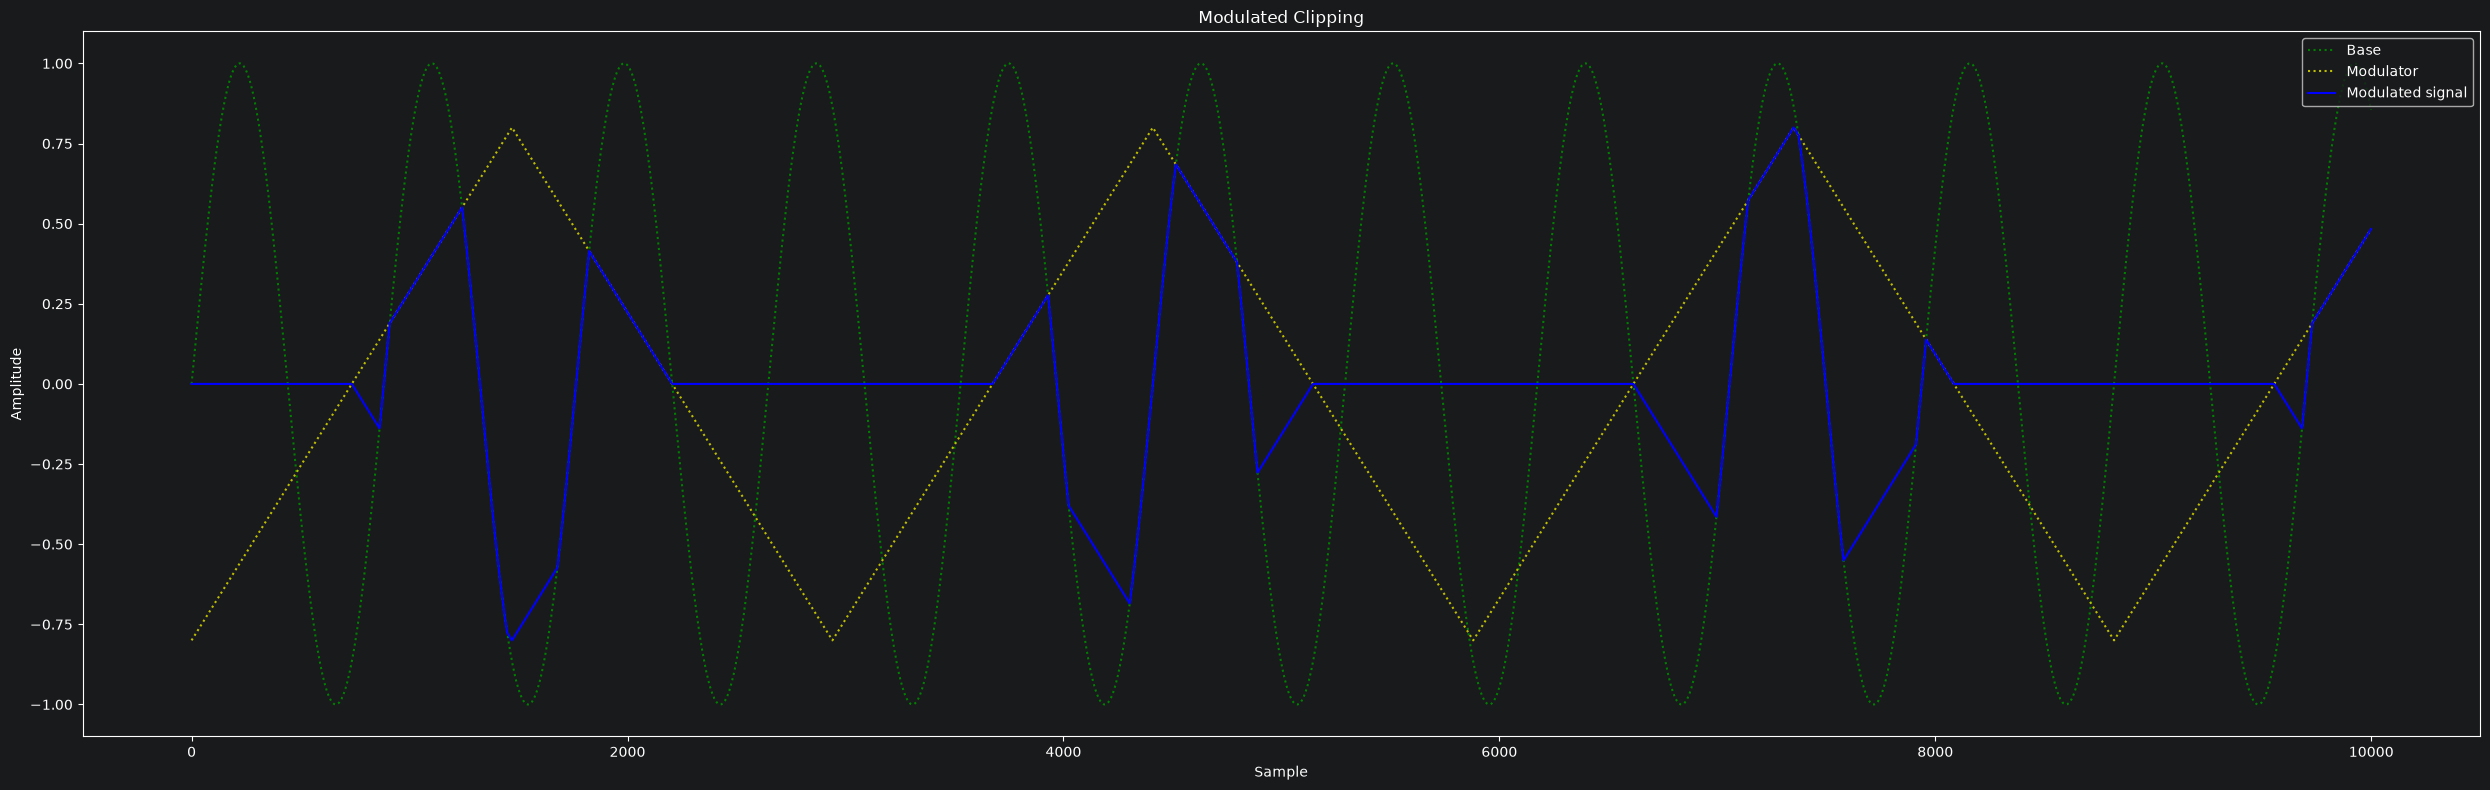

In [7]:
import matplotlib.pyplot as plt

from engine import Chain, ModulatedClipper, SineOscillator, TriangleOscillator

sine_frequency = 50
mod_frequency = 15
n = 10000

base = SineOscillator(sine_frequency)
modulator = TriangleOscillator(mod_frequency, wave_range=(-0.8, 0.8), amplitude=1.0)
gen = Chain(base, ModulatedClipper(modulator))

base_samples = base.get_samples(n=n)
modulator_samples = modulator.get_samples(n=n)
base.reset()
modulator.reset()
modulated_samples = gen.get_samples(n)

plt.subplots(1, 1, figsize=(25, 8))
plt.plot(base_samples, label="Base", linestyle=":", color="g")
plt.plot(modulator_samples, label="Modulator", linestyle=":", color="y")
plt.plot(modulated_samples, label="Modulated signal", color="b")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Modulated Clipping")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()